<a href="https://colab.research.google.com/github/Coder0469/Do-an-1/blob/main/Week9/ResNet50_FPN_Cityscapes_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
electraawais_cityscape_dataset_path = kagglehub.dataset_download('electraawais/cityscape-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'cityscape-dataset' dataset.
Data source import complete.


<a href="https://colab.research.google.com/github/Coder0469/Do-an-1/blob/main/Week3/B2_basic_pipeline_PASCALVOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">
  <h3>Kiểm tra GPU được cấp phát</h3>
</div>

In [1]:
!nvidia-smi

Fri Nov 21 03:32:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

<div class="markdown-google-sans">
  <h3>Cài đặt bổ sung một số thư viện</h3>
</div>
Nền tảng Google Colab cung cấp môi trường với các thư viện Machine Learning, Deep Learning cơ bản đã được cài đặt sẵn, phần này sẽ cài đặt một số thư viện sử dụng thêm.

In [3]:
!pip install segmentation_models_pytorch
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 23.9 MB/s eta 0:00:0000:01


<div class="markdown-google-sans">
  <h3></h3>
</div>


<div class="markdown-google-sans">
  <h3>Import thư viện</h3>
</div>

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchmetrics
from torchmetrics import  JaccardIndex
from torchmetrics.segmentation import DiceScore
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor
import os
from tqdm import tqdm
from glob import glob
import time

<div class="markdown-google-sans">
  <h3>Định nghĩa Dataset</h3>
</div>
Viết class kế thừa từ class Dataset cung cấp sẵn trong PyTorch để đọc dữ liệu từ ổ cứng. Yêu cầu viết đủ 3 hàm __init__() để khởi tạo class, __len__() để trả về số điểm dữ liệu có trong tập dữ liệu và __getitem__() trả về 1 điểm dữ liệu cụ thể. Trong phần này, do tập dữ liệu PASCAL VOC đã rất phổ biến nên sẽ tận dụng Class Dataset đã được viết sẵn. Tham khảo thêm: https://albumentations.ai/docs/autoalbument/examples/pascal_voc/


(1024, 2048)


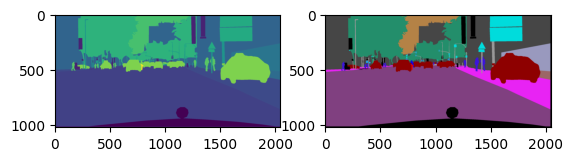

In [5]:

img = cv2.imread("/kaggle/input/cityscape-dataset/Fine Annotations/gtFine/train/aachen/aachen_000005_000019_gtFine_labelIds.png")
mask = cv2.imread("/kaggle/input/cityscape-dataset/Fine Annotations/gtFine/train/aachen/aachen_000005_000019_gtFine_color.png")
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
# mask = cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)
print(img.shape)
plt.subplot(121)
plt.imshow(img)
plt.subplot(122)
plt.imshow(mask)
# print(torch.unique(torch.from_numpy(mask.reshape(-1,3)),dim=0))


In [16]:
trainsize = 128

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Blur(),
    A.Sharpen(),
    A.Rotate(limit=45, p=0.8),
    # A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.5),
    A.RGBShift(),
    # A.CoarseDropout(
    #     num_holes_range=(1, 10),
    #     hole_height_range=(10, 10,
    #     hole_width_range=(10, 10),
    #     fill=0,
    #     p=0.5
    # ),
    A.RandomBrightnessContrast(
            brightness_limit=0.1,
            contrast_limit=0.1,
            p=1.0),
    A.HueSaturationValue(p=1.0),
    # A.ISONoise(p=0.5),
    # A.OneOf(
    #         [
    #             A.CLAHE(p=1),
    #             A.RandomBrightnessContrast(p=1),
    #             A.RandomGamma(p=1),
    #         ],
    #         p=0.9,
    #     ),
        # A.OneOf(
        #     [
        #         A.Sharpen(p=1),
        #         A.Blur(blur_limit=3, p=1),
        #         A.MotionBlur(blur_limit=3, p=1),
        #     ],
        #     p=0.9,
        # ),
        # A.OneOf(
        #     [
        #         A.RandomBrightnessContrast(p=1),
        #         A.HueSaturationValue(p=1),
        #     ],
        #     p=0.9,
        # ),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

test_transform = A.Compose([
    # A.Resize(width=trainsize, height=trainsize),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(), # numpy.array -> torch.tensor (B, 3, H, W)
])

In [7]:
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, root_dir, label_dir=None,txt_file=None, transform=None):
        super().__init__()
        self.root_dir = root_dir
        self.label_dir = label_dir
        self.transform = transform
        self.list_img = []
        self.txt_file = txt_file
        self.list_label_img = []
        folders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
        for folder in folders:
            for f in os.listdir(os.path.join(root_dir, folder)):
                self.list_img.append(os.path.join(folder,f))
        self.list_img.sort()
        if label_dir is not None:
            label_folders = [f for f in os.listdir(label_dir) if os.path.isdir(os.path.join(label_dir, f))]
            for folder in label_folders:
                for f in os.listdir(os.path.join(label_dir, folder)):
                    if f.endswith("labelIds.png"):
                        self.list_label_img.append(os.path.join(folder,f))
            self.list_label_img.sort()

    def __len__(self):
        return len(self.list_img)

    @staticmethod
    def _convert_to_segmentation_mask(mask):
        # This function converts a mask from the Pascal VOC format to the format required by AutoAlbument.
        #
        # Pascal VOC uses an RGB image to encode the segmentation mask for that image. RGB values of a pixel
        # encode the pixel's class.
        #
        # AutoAlbument requires a segmentation mask to be a NumPy array with the shape [height, width, num_classes].
        # Each channel in this mask should encode values for a single class. Pixel in a mask channel should have
        # a value of 1.0 if the pixel of the image belongs to this class and 0.0 otherwise.
        height, width = mask.shape[:2]
        segmentation_mask = np.zeros((height, width, len(COLORMAP)), dtype=np.float32)
        for label_index, label in enumerate(COLORMAP):
            segmentation_mask[:, :, label_index] = np.all(mask == label, axis=-1).astype(float)
        return segmentation_mask #0, 1, 2, 3, ..., 20 (H, W, C) -> (H, W, 1) -> (H, W) #numpy

    def __getitem__(self, idx):
        img = self.list_img[idx]
        img_path = os.path.join(self.root_dir, img)
        # print(img_path)
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (trainsize, trainsize))
        if self.label_dir is not None:
            mask_img = self.list_label_img[idx]
            mask_path = os.path.join(self.label_dir, mask_img)
            # print(mask_path)
            mask = cv2.imread(mask_path)
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
            mask = cv2.resize(mask, (trainsize,trainsize),interpolation=cv2.INTER_NEAREST)
            arr = np.array(mask, dtype=np.uint8)
            mask = np.where(arr > 0, arr - 1, arr)

            # mask = self._convert_to_segmentation_mask(mask)




        # Ensure mask values are within the valid range [0, num_classes - 1]
        # Assuming 12 classes (0-11) based on model setup
        # mask[mask >= 12] = 0 # Map invalid indices to 0

        if self.transform is not None:
            if self.label_dir is not None:
                transformed = self.transform(image=image, mask=mask)
                image = transformed['image']
                mask = transformed['mask']
            else:
                transformed = self.transform(image=image)
                image = transformed['image']
                return image
        else:
            image = torch.from_numpy(image).float().permute(2, 0, 1) / 255.0
            if self.label_dir is not None:
                mask = torch.from_numpy(mask).long()

            else:
                return image

        # Print unique mask values after transformation for debugging
        # print(f"Unique mask values after transform: {torch.unique(mask)}")

        return image, mask

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 14, 16, 18, 19, 20, 21,
        22, 23, 24, 25, 26, 27, 31, 32])


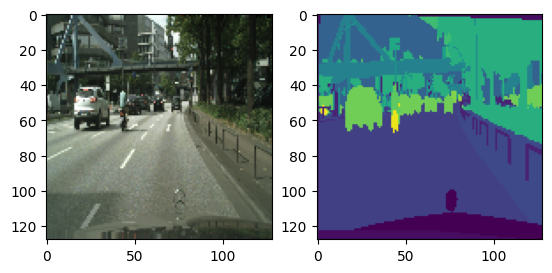

In [13]:
import random
train_dataset = MyDataset("/kaggle/input/cityscape-dataset/Cityscape Dataset/leftImg8bit/train",
                          "/kaggle/input/cityscape-dataset/Fine Annotations/gtFine/train")
id = random.randint(0, train_dataset.__len__()) # Added 0 as the lower bound
img,mask = train_dataset.__getitem__(1272)
classes = torch.unique(mask.reshape(1,-1))
print(classes)
plt.subplot(121);plt.imshow(img.permute(1,2,0))
plt.subplot(122);plt.imshow(mask)
plt.show()
# print(mask.shape)


<div class="markdown-google-sans">
  <h3>Định nghĩa các phép augmentation trên ảnh</h3>
</div>
Sử dụng thư viện Albumentations, tham khảo thêm: https://albumentations.ai/docs/api_reference/full_reference/

<div class="markdown-google-sans">
  <h3>Đoạn code dùng để convert ảnh sau khi đã chuẩn hoá thành ảnh ban đầu</h3>
</div>

In [9]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
            # The normalize code -> t.sub_(m).div_(s)
        return tensor

unorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

<div class="markdown-google-sans">
  <h3>Kiểm tra 1 cặp ảnh đầu vào và ảnh kết quả phân vùng trước khi đưa vào mô hình training</h3>
</div>

In [17]:
# train_dataset = PascalVOCSearchDataset(image_set="train", download=True, transform=train_transform)
# test_dataset = PascalVOCSearchDataset(image_set="val", download=False, transform=test_trainsform)
train_dataset = MyDataset("/kaggle/input/cityscape-dataset/Cityscape Dataset/leftImg8bit/train",
                          "/kaggle/input/cityscape-dataset/Fine Annotations/gtFine/train",
                            transform=train_transform)
val_dataset = MyDataset("/kaggle/input/cityscape-dataset/Cityscape Dataset/leftImg8bit/val",
                          "/kaggle/input/cityscape-dataset/Fine Annotations/gtFine/val",
                          transform=test_transform)


Train len: 2975
Val len: 500
tensor([ 0,  2,  3,  6,  7, 10, 16, 19, 20, 21, 22, 23, 24, 25, 32],
       dtype=torch.uint8)


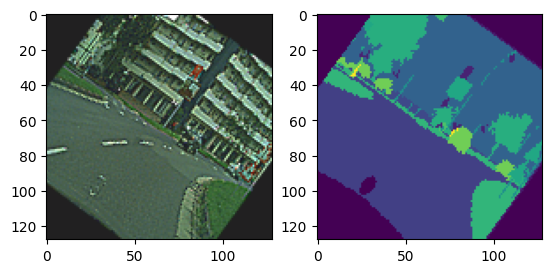

In [18]:
print("Train len: {}".format(train_dataset.__len__()))
print("Val len: {}".format(val_dataset.__len__()))
image, mask = train_dataset.__getitem__(0)
print(torch.unique(mask.reshape(1,-1)))
plt.subplot(1, 2, 1)
plt.imshow(unorm(image).permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.show()

In [19]:
class EarlyStopping():
    """
    Stops training when loss stops decreasing in a PyTorch module.
    """
    def __init__(self, patience:int = 6, min_delta: float = 0, weights_path: str = 'weights.pt'):
        """
        :param patience: number of epochs of non-decreasing loss before stopping
        :param min_delta: minimum difference between best and new loss that is considered
            an improvement
        :paran weights_path: Path to the file that should store the model's weights
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.weights_path = weights_path

    def __call__(self, val_loss: float, model: torch.nn.Module):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.weights_path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def load_weights(self, model: torch.nn.Module):
        """
        Loads weights of the best model.
        :param model: model to which the weigths should be loaded
        """
        return model.load_state_dict(torch.load(self.weights_path))

In [20]:
from segmentation_models_pytorch.encoders import get_encoder_names

get_encoder_names()

['resnet18',
 'resnet34',
 'resnet50',
 'resnet101',
 'resnet152',
 'resnext50_32x4d',
 'resnext101_32x4d',
 'resnext101_32x8d',
 'resnext101_32x16d',
 'resnext101_32x32d',
 'resnext101_32x48d',
 'dpn68',
 'dpn68b',
 'dpn92',
 'dpn98',
 'dpn107',
 'dpn131',
 'vgg11',
 'vgg11_bn',
 'vgg13',
 'vgg13_bn',
 'vgg16',
 'vgg16_bn',
 'vgg19',
 'vgg19_bn',
 'senet154',
 'se_resnet50',
 'se_resnet101',
 'se_resnet152',
 'se_resnext50_32x4d',
 'se_resnext101_32x4d',
 'densenet121',
 'densenet169',
 'densenet201',
 'densenet161',
 'inceptionresnetv2',
 'inceptionv4',
 'efficientnet-b0',
 'efficientnet-b1',
 'efficientnet-b2',
 'efficientnet-b3',
 'efficientnet-b4',
 'efficientnet-b5',
 'efficientnet-b6',
 'efficientnet-b7',
 'mobilenet_v2',
 'xception',
 'timm-efficientnet-b0',
 'timm-efficientnet-b1',
 'timm-efficientnet-b2',
 'timm-efficientnet-b3',
 'timm-efficientnet-b4',
 'timm-efficientnet-b5',
 'timm-efficientnet-b6',
 'timm-efficientnet-b7',
 'timm-efficientnet-b8',
 'timm-efficientnet-l2'

<div class="markdown-google-sans">
  <h3>Tạo AverageMeter</h3>
</div>
AverageMeter có nhiệm vụ lưu lại giá trị trung bình của độ chính xác, giá trị hàm loss, ... trong suốt quá trình training. Tham khảo thêm: https://discuss.pytorch.org/t/meaning-of-parameters/10655

In [21]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0


    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


In [22]:
class ArrayMeter:
    def __init__(self,classes):
        self.classes = classes
        self.reset()

    def reset(self):
        self.Array = np.zeros(len(self.classes),dtype = np.float64)
        self.count = 0

    def update(self,values):
        self.Array += values
        self.count += 1
        self.mArray = self.Array/self.count


In [23]:
IoU = ArrayMeter(classes = [1,2,3])
IoU.update([2,3,4])

print(IoU.mArray)

[2. 3. 4.]


<div class="markdown-google-sans">
  <h3>Lập trình hàm tính toán độ chính xác</h3>
</div>

In [24]:
#accuracy fn
def accuracy_function(preds, targets):
    preds_flat = preds.flatten()
    targets_flat = targets.flatten()
    acc = torch.sum(preds_flat == targets_flat)
    return acc/targets_flat.shape[0]

In [25]:
def CalcIntersectUnion(pred, target, classes):
    pred_label = torch.argmax(pred, dim=1)

    intersections = []
    unions = []
    predandtars = []
    for cls in classes:
        pred_cls = (pred_label == cls)
        target_cls = (target == cls)

        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()
        pred_sum = pred_cls.sum().item()
        target_sum = target_cls.sum().item()

        if pred_sum + target_sum == 0:
            dice = 1e-7

        if union == 0:
            iou = 1e-7  # hoặc 1.0 tuỳ bài toán
        intersections.append(intersection)
        unions.append(union)
        predandtars.append(pred_sum + target_sum)


    return intersections, unions, predandtars

<div class="markdown-google-sans">
  <h3>Chuẩn bị cho quá trình training</h3>
</div>


1.   Lựa chọn device: PyTorch yêu cầu lựa chọn cụ thể device sẽ train và yêu cầu người dùng tự move dữ liệu, mô hình vào device đã lựa chọn. Device có thể là "cuda" - tức là GPU NVIDIA hoặc "cpu".
2.   Định nghĩa DataLoader, khác với Dataset là cách đọc dữ liệu từ ổ cứng, DataLoader ghép nhiều điểm dữ liệu vào cùng nhau tạo thành 1 batch để đưa vào train mô hình. Lưu ý thêm: batch_size nên đặt là 4, 8, 16, 32, ... và nên để lớn nhất có thể
3.   Khởi tạo mô hình
4.   Khởi tạo hàm loss
5.   Khởi tạo thuật toán tối ưu (optimizer)
6.   Khởi tạo các độ đo sẽ sử dụng để đánh giá hiệu năng của mô hình. Phần này sẽ sử dụng các hàm độ đo Dice và IoU được lập trình sẵn trong thư viện torchmetrics
7.   Khởi tạo từng AverageMeter để lưu lại giá trị của từng độ đo, giá trị hàm loss, thời gian train, ... trong suốt quá trình train



In [26]:
def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    # 'K' classes, output and target sizes are N or N * L or N * H * W, each value in range 0 to K - 1.
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

In [27]:
#device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
Classes = [6,7,10,13,16,18,20,21,22,23,24,25,27,31,32]
#load data
batch_size = 64
n_workers = 4
print("num_workers =", n_workers)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=n_workers)
testloader = torch.utils.data.DataLoader(val_dataset, batch_size=2,
                                          shuffle=False, num_workers=n_workers)

data_classes = 33
#model
model = smp.FPN(encoder_name='resnet50', encoder_depth=5, encoder_weights='imagenet',
                decoder_pyramid_channels=256, decoder_segmentation_channels=128,
                decoder_merge_policy='add', decoder_dropout=0.2,
                decoder_interpolation='bilinear',
                in_channels=3, classes=data_classes, activation=None,
                upsampling=4, aux_params=None).to(device)
#loss
# criterion = nn.CrossEntropyLoss()
DiceLoss = smp.losses.DiceLoss(mode="multiclass",classes=None)
# IoULoss = smp.losses.JaccardLoss(mode="multiclass",classes=None)

#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
n_eps = 1

#meter
train_loss_meter = AverageMeter()
train_intersection_meter = AverageMeter()
train_union_meter = AverageMeter()
train_target_meter = AverageMeter()
train_acc_meter = AverageMeter()
train_iou_meter_perclass = AverageMeter()


val_loss_meter = AverageMeter()
val_intersection_meter = AverageMeter()
val_union_meter = AverageMeter()
val_target_meter = AverageMeter()
val_acc_meter = AverageMeter()
val_Intperclass = ArrayMeter(Classes)
val_Uniperclass = ArrayMeter(Classes)
val_PredandTar = ArrayMeter(Classes)

time_execute_GPU = AverageMeter()
time_execute_CPU = AverageMeter()

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

early_stopping = EarlyStopping(patience=30)

cuda:0
num_workers = 4


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# state_dict = torch.load("/kaggle/input/resnet50-pspnet-cityscapes/pytorch/default/5/PSP_Cityscapes.pth",
#                        map_location=torch.device(device))

# # Load the state dictionary into the model
# model.load_state_dict(state_dict)
# print("Model loaded successfully!")

In [40]:
torch.save(model.state_dict(), "FPN_Cityscapes.pth")

<div class="markdown-google-sans">
  <h3>Training thôi ...</h3>
</div>
Tham khảo thêm cách viết code training trong PyTorch: https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

In [ ]:
for ep in range(1, 1+n_eps):
    train_loss_meter.reset()
    train_acc_meter.reset()
    train_intersection_meter.reset()
    train_union_meter.reset()
    train_target_meter.reset()

    for batch_id, (x, y) in enumerate(tqdm(trainloader), start=1):
        model.train()
        optimizer.zero_grad()
        n = x.shape[0]
        x = x.to(device).float()
        y = y.to(device).long()
        y_hat = model(x) #(B, C, H, W)
        # loss = criterion(y_hat, y)
        # loss = IoULoss(y_hat,y)
        loss = DiceLoss(y_hat, y) #(B, C, H, W) >< (B, H, W)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            y_hat_mask = y_hat.argmax(dim=1).squeeze() # (B, C, H, W) -> (B, 1, H, W) -> (B, H, W)
            intersection, union, target = intersectionAndUnionGPU(y_hat_mask.float(), y.float(), data_classes)

            train_loss_meter.update(loss.item(), n)
            train_intersection_meter.update(intersection)
            train_union_meter.update(union)
            train_target_meter.update(target)
            train_accuracy = accuracy_function(y_hat_mask, y.long())
            train_acc_meter.update(train_accuracy.item(), n)

    with torch.no_grad():
        iou_class = train_intersection_meter.sum / (train_union_meter.sum + 1e-10) #vector 21D
        dice_class = (2 * train_intersection_meter.sum) / (train_intersection_meter.sum + train_union_meter.sum + 1e-10) #vector 21D

        mIoU = torch.mean(iou_class) #mean vector 21D
        mDice = torch.mean(dice_class) #mean vector 21D
    print("EP {}, accuracy = {} train loss = {} IoU = {}, dice = {}".format(ep,train_acc_meter.avg, train_loss_meter.avg, mIoU, mDice))

    if early_stopping(train_loss_meter.avg, model):
        early_stopping.load_weights(model)
        torch.save(model.state_dict(), "E\:\work 2.0\DL\Models\ResNet50 FPN Cityscapes\FPN_Cityscapes.pth")
        break

    torch.save(model.state_dict(), "E\:\work 2.0\DL\Models\ResNet50 FPN Cityscapes\FPN_Cityscapes.pth")
    train_losses.append(train_loss_meter.avg)
    train_accuracies.append(train_acc_meter.avg)




<>:42: SyntaxWarning: invalid escape sequence '\w'
<>:45: SyntaxWarning: invalid escape sequence '\w'
<>:42: SyntaxWarning: invalid escape sequence '\w'
<>:45: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-28867837.py:42: SyntaxWarning: invalid escape sequence '\w'
  torch.save(model.state_dict(), "E:\work 2.0\DL\Models\ResNet50 FPN Cityscapes\FPN_Cityscapes.pth")
/tmp/ipython-input-28867837.py:45: SyntaxWarning: invalid escape sequence '\w'
  torch.save(model.state_dict(), "E:\work 2.0\DL\Models\ResNet50 FPN Cityscapes\FPN_Cityscapes.pth")
100%|██████████| 47/47 [03:31<00:00,  4.51s/it]


EP 1, accuracy = 0.5877092631323999 train loss = 0.8023475800842798 IoU = 0.10649339109659195, dice = 0.14935514330863953


RuntimeError: Parent directory E:\work 2.0\DL\Models\ResNet50 FPN Cityscapes does not exist.

In [ ]:
plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
# plt.plot(val_lossed, label = 'Val Loss')
plt.title('Loss during Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
# plt.plot(val_accuracies, label = 'Val Accuracy')
plt.title('Accuracy during Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

<div class="markdown-google-sans">
  <h3>Viết code hiển thị kết quả dự đoán</h3>
</div>

In [ ]:

COLORMAP = [
        [  0,   0,   0],  #0: background
        [  0,   0, 255],  #1
        [  0, 220, 220],  #2
        [200, 200, 0],  #3: backward-faced sign
        [ 60,  20, 220],  #4
        [ 70,  70,  70],  #5
        [ 200,   0,  200],  #6: road
        [150,  250, 150],  #7: sidewalk
        [142,   0,   0],  #8
        [153, 153, 153],  #9
        [70, 70, 70],  #10: building
        [156, 102, 102],  #11
        [180, 130,  70],  #12
        [230,   0,   0],  #13: forward-faced sign
        [232,  35, 244],  #14: footbridge
        [150, 150, 75],  #15
        [90, 90, 120],  #16 pole/fence
        [156, 102, 102],  #17
        [0, 35,  70],  #18: traffic light
        [230,   0,   0],  #19
        [0,  70, 0],  #20: tree
        [0, 100, 0],  #21: grass
        [70, 130, 180],  #22: sky
        [128, 128, 0],  #23: pedestrian
        [255, 0, 0],  #24: biker
        [120,0,0],  #25: car
        [0,0,128],  #26
        [0,50,128],  #27: truck/bus
        [20,50,90],  #28
        [20,180,100],  #29
        [70,160,40],  #30
        [45,80,20],  #31: motorbike
        [20,160,140],  #32: bike
]

names = [
    "background",     # 0
    "None",           # 1
    "None",           # 2
    "backward-faced sign",     # 3
    "None",           # 4
    "None",           # 5
    "road",           # 6
    "sidewalk",       # 7
    "None",           # 8
    "None",           # 9
    "building",       # 10
    "None",           # 11
    "None",           # 12
    "forward-faced sign",           # 13
    "footbridge",     # 14
    "None",           # 15
    "pole/fence",           # 16
    "None",           # 17
    "traffic light",  # 18
    "None",           # 19
    "tree",           # 20
    "grass",          # 21
    "sky",            # 22
    "pedestrian",     # 23
    "biker",          # 24
    "car",            # 25
    "None",           # 26
    "truck/bus",      # 27
    "None",           # 28
    "None",           # 29
    "None",           # 30
    "motorbike",      # 31
    "bike",           # 32
]

In [ ]:
def validate():
    model.to(device)
    model.eval()
    val_acc_meter.reset()
    val_acc_meter.reset()
    val_intersection_meter.reset()
    val_union_meter.reset()
    val_target_meter.reset()
    val_Intperclass.reset()
    val_Uniperclass.reset()
    val_PredandTar.reset()
    time_execute_GPU.reset()

    for batch_id, (x, y) in enumerate(tqdm(testloader), start=1):
        n = x.shape[0]
        x = x.to(device).float()
        y = y.to(device).long()
        start = time.time()
        y_hat = model(x) #(B, C, H, W)
        end = time.time()
        # loss = 0.4*DiceLoss(y_hat, y) + 0.6*IoULoss(y_hat, y)
        loss = IoULoss(y_hat,y)


        with torch.no_grad():
            y_hat_mask = y_hat.argmax(dim=1).squeeze() # (B, C, H, W) -> (B, 1, H, W) -> (B, H, W)
            accuracy = accuracy_function(y_hat_mask, y.long())
            Int, Uni, PredandTar = CalcIntersectUnion(y_hat, y, Classes)
            intersection, union, target = intersectionAndUnionGPU(y_hat_mask.float(), y.float(), data_classes)

            val_loss_meter.update(loss.item(), n)
            val_intersection_meter.update(intersection)
            val_union_meter.update(union)
            val_acc_meter.update(accuracy.item(),n)
            val_target_meter.update(target)
            val_Intperclass.update(Int)
            val_Uniperclass.update(Uni)
            val_PredandTar.update(PredandTar)
            time_execute_GPU.update(end-start)


    with torch.no_grad():
        iou_class = val_intersection_meter.sum / (val_union_meter.sum + 1e-10) #vector 21D
        dice_class = (2 * val_intersection_meter.sum) / (val_intersection_meter.sum + val_union_meter.sum + 1e-10) #vector 21D

        mIoU = torch.mean(iou_class) #mean vector 21D
        mDice = torch.mean(dice_class) #mean vector 21D

    print("val loss = {}, accuracy = {}, IoU = {}, dice = {}".format(
        val_loss_meter.avg, val_acc_meter.avg, mIoU, mDice
    ))
    IoU = np.zeros(len(classes),dtype = np.float64)
    IoU = val_Intperclass.Array/val_Uniperclass.Array
    Dice = np.zeros(len(classes),dtype = np.float64)
    Dice = 2*val_Intperclass.Array/val_PredandTar.Array
    for i,class_id in enumerate(Classes):
        print("class: {} \t mIoU: {} \t mDice: {}".format(names[class_id],IoU[i],Dice[i]))
    print("GPU mean execute time: {}".format(time_execute_GPU.avg))


In [ ]:
def validate_CPU():
    model.eval()
    model.to("cpu")
    time_execute_CPU.reset()
    for i in range(0,3):
        with torch.no_grad():
            x, y = val_dataset.__getitem__(i)
            x = x.to("cpu").float()
            y = y.to("cpu").long()
            start = time.time()
            x_unsqueeze = x.unsqueeze(0)
            y_predict = model(x_unsqueeze)
            end = time.time()
            time_execute_CPU.update(end-start)
    print("CPU mean execute time: {}".format(time_execute_CPU.avg))
    model.to(device)




In [ ]:
validate()

In [ ]:
validate_CPU()

In [ ]:

for i in range(0,30):
    with torch.no_grad():
        model.eval()
        x, y = val_dataset.__getitem__(i)
        y_predict = model(x.unsqueeze(0).to(device)).argmax(dim=1).squeeze().cpu().numpy()
        # for i in np.unique(y_predict).tolist():
        #     print(CLASSES[i])
        color_mask_predict = np.zeros((*y_predict.shape, 3),dtype = np.uint8)
        for i, color in enumerate(COLORMAP):
            color_mask_predict[y_predict==i] = np.array(color)
        color_mask = np.zeros((*y_predict.shape, 3),dtype = np.uint8)
        for i, color in enumerate(COLORMAP):
            color_mask[y==i] = np.array(color)
        plt.subplot(1,3,1)
        plt.imshow(unorm(x).permute(1, 2, 0))
        plt.subplot(1,3,2)
        plt.imshow(color_mask)
        plt.subplot(1,3,3)
        plt.imshow(color_mask_predict)
        plt.show()


In [ ]:
#predict

test_dataset = MyDataset(root_dir="/kaggle/input/cityscape-dataset/Cityscape Dataset/leftImg8bit/test",
                          transform=test_transform
                          )

for i in range(0,20):
    with torch.no_grad():
        model.eval()
        x = test_dataset.__getitem__(i)
        y_predict = model(x.unsqueeze(0).to(device)).argmax(dim=1).squeeze().cpu().numpy()
        # for i in np.unique(y_predict).tolist():
        #     print(VOC_CLASSES[i])
        color_mask_predict = np.zeros((*y_predict.shape, 3),dtype = np.uint8)
        for i, color in enumerate(COLORMAP):
            color_mask_predict[y_predict==i] = np.array(color)
        plt.subplot(1,2,1)
        plt.imshow(unorm(x).permute(1, 2, 0))
        plt.subplot(1,2,2)
        plt.imshow(color_mask_predict)
        plt.show()

## VISUALIZE!!